# Modeling CWFP Clarified Turbidity Given Raw Turbidity and Coagulant Dosage Data

### **Model Derivation**

**Introduction:**

Unlike AguaClara plants which use vertical flow clarifiers, CWFP uses a horizontal flow clarifier. In CWFP's clarifier, flocs settle downwards as water flows horizontally. While flocs settle, they collide with--and capture--primary particles in a process called floc sweeping. CWFP's clarifier does not have a floc filter, which greatly simplifies the clarification model. Because there is no floc filter, flocs do not stay in the clarifier for as long. As a result, this model assumes floc saturation/exhaustion is negligable.

This derivation follows a vertical section of the clarifier with length $Δx$ as it travels through the clarifier. The water, flocs and primary particles in this section enter the clarifier over the course of a time interval $Δt$. t=0 is defined as the time when the vertical section enters the clarifier.

**Constant Definitions:**
* $m_{perFloc}$ = average mass of floc
* $r_{perFloc}$ = average radius of floc
* $a_{clarifier}$ = area of clarifier normal to fluid flow
* $t_F$ = average time that flocs settle in clarifier (dependent on height of clarifier and average floc terminal velocity)
* $v$ = clarifier horizontal flow velocity
* $v_y$ = average vertical velocity of flocs
* $Δt$ = time resolution
* $Δx = Δt*v$ horizontal distance primary particles and flocs travel in $Δt$
* $k$ = proportionality constant relating probability of primary particle capture (probability that there is a particle of coagulant at the contact point of a floc-primary particle collision) to fractional coverage of coagulant
* $k_{pf}$ = constant in flocculation model (see [AguaClara Textbook Eq 371](https://aguaclara.github.io/Textbook/Operation/Coagulant_Automation.html#equation-ccoagflocmodel))

**Variable Definitions:**
* $N_{floc}$ = number of flocs
* $C_{floc}$ = concentration of flocs
* $C_{primary}(t)$ = concentration of primary particles at time t
* $C_{primaryFlocculated}$ = concentration of primary particles when entering clarifier (post-flocculation)
* $C_{primaryCaptured}(t)$ = number of primary particles captured at time t during $Δt$
* $C_{primaryClarified}$ = concentration of primary particles after clarification
* $C_{coag}$ = concentration of coagulant entering raw water (water entering flocculator at $t=-θ_{flocculator}$)
* $C_{primaryRaw}$ = concentration of primary particles in raw water (water entering flocculator at $t=-θ_{flocculator}$)
* $α$ = attachment efficiency between primary particle and floc, dependent on the fractional coverage of coagulant

<br>
<br>

**The Flocculation Model:**

According to the [flocculation coagulant model in the AguaClara Textbook](https://aguaclara.github.io/Textbook/Operation/Coagulant_Automation.html),
$$C_{coag} = k_{pf}C_{primaryRaw}[C_{primary}(t+\theta_{flocculator})^{-\frac{2}{3}} - C_{primaryRaw}^{-\frac{2}{3}}]$$
Rewriting this equation to return the concentration of primary particles entering the clarifier after flocculation,
$$\boxed{C_{primaryFlocculated} = [\frac{C_{coag}}{k_{pf}C_{primaryRaw}}+C_{primaryRaw}^{-\frac{2}{3}}]^{-\frac{3}{2}}}$$
Using conservation of mass,
$$C_{floc} = C_{primaryRaw} - C_{primaryFlocculated}$$

<br>
<br>

**Determining $C_{primaryClarified}$:**

$$C_{primaryCaptured}(t) = [\text{attachment efficiency}][\text{fraction of volume 'swept' by flocs during Δt}][\text{concentration of primary particles}]=α\frac{N_{floc}πr_{perFloc}^2v_yΔt}{a_{clarifier}Δx}C_{primary}(t)$$

Number of flocs can be written in terms of concentration, followed by substituting $C_{floc}$:
$$N_{floc} = \frac{C_{floc}a_{clarifier}Δx}{m_{perFloc}} = \frac{[C_{primaryRaw} - C_{primaryFlocculated}]a_{clarifier}Δx}{m_{perFloc}}$$

Attachment efficiency $\alpha$ is proportional to the ratio of coagulant dosage to clay (eg. raw turbidity):
$$\alpha = k\frac{C_{coag}}{C_{primaryRaw}}$$

 Substituting $N_{floc}$, $\alpha$, and $Δx=Δt*v$, and defining a new constant $γ = \frac{k\pi r_{perFloc}^2v_y}{m_{perFloc}}$,
$$C_{primaryCaptured}(t) = γC_{primary}(t)\frac{C_{coag}[C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}Δt$$

Since
$$C_{primary}(t+Δt) = C_{primary}(t) - C_{primaryCaptured}(t)$$
then substituting,
$$C_{primary}(t+Δt) - C_{primary}(t) = - C_{primaryCaptured}(t) = -γC_{primary}(t)\frac{C_{coag}[C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}Δt$$

Taking the limit as $Δt$ approaches 0,
$$dC_{primary}(t) = -γC_{primary}(t)\frac{C_{coag}[C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}dt$$
Separating variables and integrating,
$$∫_{C_{primaryFlocculated}}^{C_{primaryClarified}}\frac{1}{C_{primary}(t)}dC_{primary}(t) = ∫_{0}^{t_F}-γ\frac{C_{coag}[C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}dt$$

$$\boxed{C_{primaryClarified} = C_{primaryFlocculated}e^{-γ\frac{C_{coag}[C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}t_F}}$$


<br>
<br>

Using these equations, we can predict clarified turbidity given raw turbidity and coagulant dosage.

**Key Assumptions:**
* Floc saturation is negligable
* Primary particles in clarifier are uniformly distributed (well-mixed)
* Coagulant responds immediately to changes in dosage
* Flocs are not right on top of each other (there is fluid and primary particles between all flocs)
* Flocs are spherical

### **Adding DOM**

**Constant Definitions:**
* $C_{DOM}$ = concentration of DOM in raw water
* $C_{coag}$ = actual coagulant dosage
* $C_{coagEffective}$ = effective coagulant dosage, considering coagulant used by DOM
* $\lambda$ = proportionality constant indicating the mass of coagulant used per mass of DOM

**Derivation:**

[Du et al., 2019](https://doi.org/10.1089/ees.2018.0405) provides a theory on how DOM affects coagulant dosage. Their findings suggest that coagulant only becomes available to primary particles and flocs after all of the DOM coats coagulant particles. As a result, the effective concentration of coagulant for flocculation and clarification processes is reduced proportional to the concentration of DOM:
$$C_{coagEffective} = C_{coag} - \lambda C_{DOM}$$

Substituting $C_{coagEffective}$ for $C_{coag}$ in the prior equations,
$$\boxed{C_{primaryFlocculated} = [\frac{C_{coag} - \lambda C_{DOM}}{k_{pf}C_{raw}}+C_{primaryRaw}^{-\frac{2}{3}}]^{-\frac{3}{2}}
\\C_{primaryClarified} = C_{primaryFlocculated}e^{-γ\frac{[C_{coag} - \lambda C_{DOM}][C_{primaryRaw} - C_{primaryFlocculated}]}{C_{primaryRaw}}}}$$

### Fitting Model to CWFP Data



<img src='https://drive.google.com/uc?id=1I-D8pwqLGPYekIMqd7KCr2i0Qb9OST-V' width="500"/>
<img src='https://drive.google.com/uc?id=1namDuA1JwzfrShZJRbnfNQFdJPLeRqgz' width="500"/>
<img src='https://drive.google.com/uc?id=1Soeo0lZ1jmlDISsISuTxMRFxa0cjRilx' width="500"/>
<img src='https://drive.google.com/uc?id=1XX0onICo4VnCHYjqbAJINW8aYEz8sZ0t' width="500"/>

<br>

**Notes:**
* [Data](https://docs.google.com/spreadsheets/d/1ckFXuX6b6mco0QqXXONacCxxfhgx2-ij/edit?usp=sharing&ouid=114827095086734670216&rtpof=true&sd=true)
* 1156 data points
* Clarified turbidity and clarified DOM data were shifted to align with raw turbidity, coagulant dose, and raw DOM data from 30 minutes prior. 30 minutes is the estimated time for settled turbidity to respond to a change in coagulant dosing according to CWFP operators).
* Not including DOM ($λ=0$) resulted in the following parameter values with 95% confidence intervals:
$$k_{pf} = 3.888\hspace{1cm}(3.565, 4.211)$$
$$γ = 0.06464\hspace{1cm}(0.0607, 0.0686)$$
* $C_{DOM} = C_{DOMraw} - C_{DOMsettled}$
* Including DOM (a non-zero $λ$) in the model resulted in the following parameter values:
$$k_{pf} = 3.2426$$
$$γ = 0.0214$$
$$λ = -107.6578$$
The unexpected negative result for $λ$ may be explained by the positive, non-orthogonal relationship between DOM and raw turbidity (see graph above). This suggests that these two variables cannot be modeled as independent variables. Additionally, it is possible that UV254 measurements are influenced by clay particles and are not solely measuring DOM.

### **MATLAB Code:**

```
%% PREPROCESSING

% Need to manually add data to workspace in the following data order:
% raw turb, coag dose, settled turb, raw uva, settled uva

% remove all rows of data where values are 0 (so model doesn't give division by 0 error)
data(data(:,1)==0,:) = [];
data(data(:,2)==0,:) = [];
data(data(:,3)==0,:) = [];
data(data(:,4)==0,:) = [];
data(data(:,5)==0,:) = [];

% exclude outliers
% data = data(data(:,1)<=200,:);
% data = data(data(:,3)<=1,:);
% data = data(data(:,4)-data(:,5)<=0.3,:);
% data = data(data(:,4)-data(:,5)>=0,:);

% extract specific variables (eg. turb, coag dose, dom) from data
shift = 1; % shift (measured in # of data intervals) due to HRT causing response delay between raw and settled
raw_turb = data(shift+1:end,1);
coag = data(shift+1:end,2);
settled_turb = data(1:end-shift,3);
raw_dom = data(shift+1:end,4);
settled_dom = data(1:end-shift,5);
dom = raw_dom - settled_dom;




%% Fit data without DOM

% Calculate fit
[xData, yData, zData] = prepareSurfaceData( raw_turb, coag, settled_turb );
ft = fittype( '(1/a*y/x+x^(-2/3))^(-3/2)*exp(-b*(x-(1/a*y/x+x^(-2/3))^(-3/2))*y/x)', 'independent', {'x', 'y'}, 'dependent', 'z');
opts = fitoptions( 'Method', 'NonlinearLeastSquares' );
opts.Display = 'Off';
opts.StartPoint = [.3 0.5];
[Fit, gof] = fit( [xData, yData], zData, ft, opts );

% Plot fit
figure( 'Name', 'Model fit' );
h = plot( Fit, [xData, yData], zData );
legend( h, 'model', 'actual data', 'Location', 'NorthEast', 'Interpreter', 'none' );
xlabel( 'Raw Turbidity (NTU)', 'Interpreter', 'none' );
ylabel( 'Coagulant Dosage (PPM)', 'Interpreter', 'none' );
zlabel( 'Clarified Turbidity (NTU)', 'Interpreter', 'none' );
title("CWFP May-June 2023 Model")
grid on
zlim([0 max(settled_turb)])




%% Fit data with DOM
% b(1) = kpf, b(2) = γ, b(3) = λ
modelfun = @(b,x)( (1./b(1).*(x(:,2)-b(3).*x(:,3))./x(:,1)+x(:,1).^(-2/3)).^(-3/2).*exp(-b(2).*(x(:,1)-(1./b(1).*(x(:,2)-b(3).*x(:,3))./x(:,1)+x(:,1).^(-2/3)).^(-3/2)).*(x(:,2)-b(3).*x(:,3))./x(:,1))  );
beta0 = [1 1 1];
opts = statset('nlinfit');
opts.FunValCheck = 'off';
opts.TolFun = 1e-8;
[beta] = nlinfit([raw_turb,coag,dom],settled_turb,modelfun,beta0,opts);

% Plot fit
settled_turb_modeled = modelfun(beta,[raw_turb,coag,dom]);
hold on;
scatter3(raw_turb,coag,settled_turb,'filled','LineWidth',0.1)
scatter3(raw_turb,coag,settled_turb_modeled,'filled','LineWidth',0.1)
xlabel( 'Raw Turbidity (NTU)', 'Interpreter', 'none' );
ylabel( 'Coagulant Dosage (PPM)', 'Interpreter', 'none' );
zlabel( 'Clarified Turbidity (NTU)', 'Interpreter', 'none' );
legend("actual data","modeled data")
title("CWFP May-June 2023 Model with DOM")
hold off;
```

# Predicting Clarified Turbidity Given Raw Turbidity and Coagulant Dosage Data

TODO
*   main flow rate affects upflow velocity - assuming 1mm/s for now
*   delay in coagulant dosing response
*   add DOM - add after fitting regression

###**Model Derivation**
#####(Vertical Floc Filter Clarifier)

This derivation follows a horizontal section of the clarifier with height $Δh$ as it travels through the clarifier. The water, flocs and primary particles in this section travel through a height $Δh$ over the course of a time interval $Δt$. t=0 is defined as the time when the vertical section enters the clarifier. h=0 is defined as the bottom of the clarifier.

**Constant Definitions:**
* $\theta_{flocculator}$ = hydraulic residence time of flocculator
* $a_{flocFilter}$ = area of floc filter
* $h_{flocFilter}$ = height of floc filter
* $v$ = average upflow velocity of primary particles through clarifier
* $C_{floc}$ = average concentration of flocs in floc filter
* $M_{totalFloc} = C_{floc}V_{flocFilter}$ = total mass of flocs in floc filter
* $m_{perFloc}$ = average mass per floc
* $r_{perFloc}$ = average diameter per floc
* $\beta$ = proportionality constant relating probability of primary particle capture to floc's fraction of saturation
* $k_{pf}$ = constant in flocculation model (see [AguaClara Textbook Eq 371](https://aguaclara.github.io/Textbook/Operation/Coagulant_Automation.html#equation-ccoagflocmodel))
$$k_{pf} = \frac{3}{2\pi kk^{'}G\theta}(\rho_{P}\frac{\pi}{6})^{2/3}$$
* $q$ = average mass of primary particles that can be captured per mass of floc
* $k'$ = proportionality constant relating probability of primary particle capture (probability that there is a particle of coagulant at the contact point of a floc-primary particle collision) to fractional coverage of coagulant

**Variable Definitions:**
* $C_{primaryRaw}$ = raw concentration of primary particles entering flocculator
* $C_{coag}$ = concentration of coagulant entering raw water
* $C_{primaryFlocculated}$ is concentration of primary particles after flocculation / entering clarifier
* $C_{primary}(t)$ is concentration of primary particles in clarifier at time t
* $C_{primaryClarified}$ is clarified concentration of primary particles
* $C_{primaryCaptured}(t)$ = concentration of primary particles captured in floc filter during $Δt$ at time t
* $C_{flocEntering}$ = concentration of flocs entering clarifier
* $\alpha$ = probability that there is a particle of coagulant at the contact point of a floc-primary particle collision in the floc filter
* $P_{flocSaturated}$ = average percent saturation of flocs in the floc filter
* $Δt$ = time resolution/data interval
* $Δh = Δt\cdot v$ = average height that primary particles travel in $Δt$ in floc filter

<br>
<br>

**The Flocculation Model:**

According to the [flocculation coagulant model in the AguaClara Textbook](https://aguaclara.github.io/Textbook/Operation/Coagulant_Automation.html),
$$C_{coag} = k_{pf}C_{raw}\cdot[C_{primaryFlocculated}^{-\frac{2}{3}} - C_{raw}^{-\frac{2}{3}}]$$
Rewritting this equation to return the concentration of primary particles entering the clarifier after flocculation,
$$\boxed{C_{primaryFlocculated} = [\frac{C_{coag}}{k_{pf}C_{raw}}+C_{raw}^{-\frac{2}{3}}]^{-\frac{3}{2}}}$$
Using conservation of mass,
$$C_{flocEntering} = C_{raw} - C_{primaryFlocculated}$$

<br>
<br>

**Calculating $C_{primary}$ and $\alpha$:**

As primary particles flow through the clarifier, they are captured by flocs.
$$C_{primary}(t+Δt) = C_{primary}(t) - C_{primaryCaptured}(t)$$

The concentration of primary particles captured at time t in Δt can be determined based on a similar idea to the Yao Filtration Model ([Yao
et al., 1971](https://pubs.acs.org/doi/10.1021/es60058a005)),
$$C_{primaryCaptured}(t) = \frac{[\text{mass flow of primary particles to each floc in time Δt}][\text{number of flocs in Δh}][\text{attachment efficiency}]}{a_{flocFilter}Δh}$$
$$[\text{mass flow of primary particles to each floc in time Δt}]=C_{primary}(t)πr_{perFloc}^2 Δh$$

Number of flocs can be written in terms of concentration:
$$[\text{number of flocs in Δh}] = \frac{C_{floc}a_{flocFilter}Δh}{m_{perFloc}}$$

Attachment efficiency of a primary particle to a floc is proportional to the fractional coverage of coagulant, $\alpha$, and the degree of saturation of the floc, $\beta P_{flocSaturated}$:
$$[\text{attachment efficiency}] = \alpha\beta(1-P_{flocSaturated})^{\frac{2}{3}}$$
*Note the 2/3 exponent on $P_{flocSaturated}$. This is because attachment of vertically flowing primary particles is related to the cross-sectional surface area of the flocs, while $P_{flocSaturated}$ is based on volume.

$\alpha$ is proportional to the ratio of coagulant dosage to clay (eg. raw turbidity).
$$\alpha = k'\frac{C_{coag}}{C_{raw}}$$
<br>
Substituting,
$$C_{primaryCaptured}(t)=k'\frac{C_{coag}}{C_{raw}}\beta(1-P_{flocSaturated})^{\frac{2}{3}} C_{primary}(t) \frac{πr_{perFloc}^2 C_{floc}}{m_{perFloc}}Δh$$

Define a new constant $\boxed{k_c = k'\beta\frac{πr_{perFloc}^2 C_{floc}}{m_{perFloc}}}$

Substituting into the equation for $C_{primary}$,
$$C_{primary}(t+Δt) = C_{primary}(t)[1 - k_c\frac{C_{coag}}{C_{raw}}(1-P_{flocSaturated})^{\frac{2}{3}}Δh]$$

Reformatting this into a differential equation and then solving across the entire clarifier residence time,
$$\frac{dC_{primary}}{dh} = -k_c\frac{C_{coag}}{C_{raw}}(1-P_{flocSaturated})^{\frac{2}{3}}C_{primary}$$
$$∫_{C_{primaryFlocculated}}^{C_{primaryClarified}}\frac{1}{C_{primary}(t)}dC_{primary}=-∫_{0}^{h_{flocFilter}}k_c\frac{C_{coag}}{C_{raw}}(1-P_{flocSaturated})^{\frac{2}{3}}dh$$
$$\boxed{C_{primaryClarified}=C_{primaryFlocculated}e^{-k_c\frac{C_{coag}}{C_{raw}}(1-P_{flocSaturated})^{\frac{2}{3}}h_{flocFilter}}}$$
*Note: Since $e^{-x} ≈ 1-x$ for $x << 1$ and since the used datasets have $Δh$ values of ~0.05, the model below uses the first boxed equation instead of the integrated version to simplify computation. If $Δh$ is larger, modifying the code below will be necessary.

<br>
<br>

**Calculating $P_{flocSaturated}(t)$:**

*Language note: Once a primary particle joins a floc in the floc filter, its mass is accounted for in the total floc mass. So when discussing primary particle wastage, this refers to primary particles that have joined flocs and are being wasted as a result of the floc being wasted. In other words, mass of flocs = mass of original flocs + mass of primary particles that have joined the flocs.

The percent saturation of flocs in the floc filter is the ratio of primary particles mass in the floc filter to the max mass of primary particles that the floc filter can possess:
$$P_{flocSaturated}(t+Δt) = \frac{[\text{current mass of primary particles in the floc filter}] + [\text{total mass of primary particles captured during Δt}] - [\text{mass of primary particles wasted during Δt}]}{[\text{max mass of primary particles that floc filter can possess}]}$$

We could simplify the model by approximating $P_{flocSaturated}(t)$ as its value at steady state. At steady state,
$$\text{[concentration of primary particles entering clarifier]} = \text{[concentration of primary particles escaping clarifier]} + \text{[concentration of primary particles wasted via wasting flocs]}$$
*Note: we can use a concentration balance above instead of a mass balance since the volume for all of these concentrations are the same
$$\text{[concentration of primary particles entering clarifier]} = C_{primaryFlocculated}$$
$$\text{[concentration of primary particles escaping clarifier]} = C_{primaryClarified}$$
Since $\text{[concentration of flocs wasted]} = C_{flocEntering} + C_{primaryCaptured}$ assuming steady state and a constant floc blanket concentration,
$$\text{[concentration of primary particles wasted via wasting flocs]} = q(C_{flocEntering}+C_{primaryFlocculated}-C_{primaryClarified})P_{flocSaturated}$$

Substituting,
$$C_{primaryFlocculated} = C_{primaryClarified} + q(C_{raw}-C_{primaryClarified})P_{flocSaturated}$$
Rearranging,
$$\boxed{P_{flocSaturated} = \frac{C_{primaryFlocculated} - C_{primaryClarified}}{q(C_{raw}-C_{primaryClarified})}}$$
<br>
<br>

Using these equations, we can simulate primary particle and floc flow through the clarifier. This allows us to predict clarified turbidity and the saturation of the floc filter given raw turbidity and coagulant dosage time series data.

$$\boxed{C_{primaryFlocculated} = [\frac{C_{coag}}{k_{pf}C_{raw}}+C_{raw}^{-\frac{2}{3}}]^{-\frac{3}{2}}
\\C_{primaryClarified}=C_{primaryFlocculated}e^{-k_c\frac{C_{coag}}{C_{raw}}(1-P_{flocSaturated})^{\frac{2}{3}}h_{flocFilter}}
\\P_{flocSaturated} = \frac{C_{primaryFlocculated} - C_{primaryClarified}}{q(C_{raw}-C_{primaryClarified})}}$$

**Key Assumptions:**
* Concentration/mass of floc filter is constant
* Size of flocs are constant
* Capture efficiency of primary particles is proportional to the saturation of flocs
* Entering flocs are unsaturated
* The max capture of primary particles per mass of floc is constant
* Flocs in clarifier are uniformly distributed (well-mixed)
* Coagulant responds immediately to changes in dosage
* Flocs are spherical

**Model Constants Summary**
*   $k_{pf}$ = flocculation constant
    * decreased $k_{pf}$ -> increased flocculation performance
*   $k_c$ = clarification constant, dependent on physical unknowns (average diameter of flocs, proportionality constant relating probability of primary particle capture to floc's fraction of saturation, transport efficiency of primary particles to floc in floc filter)
    * increased $k_c$ -> increased clarification performance
*   $q$ = average mass of primary particles that can be captured per mass of floc -- particle capture capacity of flocs [clarification]
    * increased $q$ -> increased clarification performance

### **MODEL FITTING**
Setup:
1.   Import datasets as .xlsx into this Google Colab file
2.   Edit the code below to read in the appropriate data file and column names, and change the value of dt based on the datasets' data interval

In [ ]:
##IMPORTS
import numpy as np
np.set_printoptions(precision=5)
import math
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.optimize import minimize, Bounds, root_scalar
from google.colab import files

In [ ]:
##COMPILE DATASETS INTO 1 LIST
# BEFORE RUNNING, ADD DATASETS TO COLAB
allData = []
for file in os.listdir():
  if file.endswith(".xlsx"):
        allData.append(pd.read_excel(file, 'Untitled'))
len(allData)

#Becca's suggestions
#take random sample of 10% of dataset for testing
#use the other 90% for training
#after training, use model to predict for all of the testing data
#decide a metric for performance: cumulative error? classification? whatever is most useful
#if it is overfit, lower max_iter

3

In [ ]:
##FUNCTION DEFINITION
def calc_C_flocculated(C_coag,C_raw,param):
  return (C_raw**(-2/3) + C_coag/(param[0]*C_raw))**(-3/2);

# def calc_C_clarified(C_coag,C_raw,C_flocculated,param,height_ff,P):
#   return C_flocculated * math.exp(-param[1]*height_ff*C_coag/C_raw*(1-P)**(2/3));

# def calc_percent_saturation_unfiltered(C_raw,C_flocculated,C_clarified,param):
#   return (C_flocculated-C_clarified)/(param[2]*(C_raw-C_clarified));

# def calc_dom_min(dom,C_coag,C_raw,C_clarified,param,height_ff,P):
#   return (C_clarified - calc_C_clarified((C_coag-dom),C_raw,calc_C_flocculated((C_coag-dom),C_raw,param),param,height_ff,P))**2;

def model(param,data,timePoints):

    kpf = param[0]
    # k_c = param[1]
    # q = param[2]

    #Constants
    # clarified_target = 0.8*1.7 #mg/L (1.7mg/L = 1NTU)
    time_flocculation = 180    #s
    # time_clarification = 720    #s
    # height_ff = .72    #m
    # area_ff = .785    #m
    # velocity = .001    #m/s
    # C_F = 3000   #mg/L
    # M_F = C_F * height_ff * area_ff * 1000    #mg  (1000L = 1m^3)
    dt = 5 #s, data interval    DEPENDS ON DATASET

    if (timePoints == "all"):
      C_raw_NTU = data['raw [NTU]'].values    # C_raw_NTU = np.repeat(10, 1000)
      C_coag = data['coagulant [mg Al/L]'].values
      C_settled_NTU = data['floc sed [NTU]'].values
      # C_clarified_NTU = data['clarified [NTU]'].values
      # C_effluent_NTU = data['filtered [NTU]'].values
      time = data['Absolute time'].values
    else:
      C_raw_NTU = data['raw [NTU]'].values[timePoints]    # C_raw_NTU = np.repeat(10, 1000)
      C_coag = data['coagulant [mg Al/L]'].values[timePoints]
      C_settled_NTU = data['floc sed [NTU]'].values[timePoints]
      # C_clarified_NTU = data['clarified [NTU]'].values[timePoints]
      # C_effluent_NTU = data['filtered [NTU]'].values[timePoints]
      time = data['Absolute time'].values[timePoints]

    #Correct units, convert to numpy arrays
    C_raw = np.array(C_raw_NTU/3, dtype = float)   #mg/L (1.7mg/L = 1NTU) or (3 NTU = 1 mg/L)
    C_settled = np.array(C_settled_NTU/3, dtype = float)
    # C_clarified = np.array(C_clarified_NTU*1.7, dtype = float)
    # C_effluent = np.array(C_effluent_NTU*1.7, dtype = float)

    #Calculate useful constants for creating arrays
    num_time_pts = len(C_raw)
    # dh = velocity * dt
    # num_h_pts = math.floor(height_ff/dh)
    num_pts_flocculator_response_delay = math.ceil(time_flocculation/dt)
    # num_pts_clarifier_response_delay = math.ceil(time_clarification/dt)
    # zero_arr_h_pos = [0 for n in range(num_h_pts)]

    table = pd.DataFrame({
        "time": time,
        "raw_actual": C_raw,
        # "clarified_actual": C_clarified,
        # "clarified_pred": np.array([0 for m in range(num_time_pts)], dtype = float),
        # "clarified_target": np.array([clarified_target for m in range(num_time_pts)], dtype = float),
        "flocculated_actual": C_settled,
        # "effluent_actual": C_effluent,
        "coagulant_actual": C_coag,
        # "coagulant_eff": np.array([0 for m in range(num_time_pts)], dtype = float),
        "flocculated_pred": np.array([0 for m in range(num_time_pts)], dtype = float),
        # "floc_saturation": np.array([0 for m in range(num_time_pts)], dtype = float),
        # "floc_saturation_unfiltered": np.array([0 for m in range(num_time_pts)], dtype = float),
        "dom_pred": np.array([0 for m in range(num_time_pts)], dtype = float)
        # "primary_particle_conc_floc_filter": np.array([zero_arr_h_pos for m in range(num_time_pts)], dtype = float)   # indexing -> [time][h position]
    })

    opt = {'disp':True,'maxiter':65}
    bounds = Bounds(0.1, 300)

    #Solving
    for t in range(1, num_time_pts-num_pts_flocculator_response_delay):
        # previous_floc_saturation = table["floc_saturation"][t-1]

        table["flocculated_pred"][t+num_pts_flocculator_response_delay] = calc_C_flocculated(table["coagulant_actual"][t]-table["dom_pred"][t-1],table["raw_actual"][t],param)
        # table["clarified_pred"][t] =  calc_C_clarified(table["coagulant_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay]-table["dom_pred"][t-1],table["raw_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["flocculated_pred"][t-num_pts_clarifier_response_delay],param,height_ff,table["floc_saturation"][t-1]);

        # sat = calc_percent_saturation_unfiltered(table["raw_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["flocculated_pred"][t-num_pts_clarifier_response_delay],table["clarified_actual"][t],param);
        # table["floc_saturation_unfiltered"][t] = sat
        # table["floc_saturation"][t] = min(max(sat, 0),1)

        # dom_result = minimize(calc_dom_min,10,method='nelder-mead',args=(table["coagulant_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["raw_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["clarified_actual"][t],param,height_ff,table["floc_saturation"][t-1]),options=opt,bounds=bounds)
        # table["dom_pred"][t] = max(dom_result.x,0);
        # table["coagulant_eff"][t] = table["coagulant_actual"][t] - max(dom_result.x,0);
        # print(table.iloc[t])

    #Calculate error
    error = sum((table["flocculated_pred"] - table["flocculated_actual"])**2)

    return table, error

In [ ]:
##FUNCTION DEFINITION
##Loop through datasets and solve
def solve(param,allData):

  totalError = 0
  for d in range(len(allData)):

    #Get specific dataset
    data = allData[d]

    table, error = model(param,data,range(400,1000))

    #Calculate error
    totalError = totalError + error

  return totalError

In [ ]:
param0 = [1] # param0 = [1.9,50,.06] #kpf, k_c,q
opt = {'disp':True,'maxiter':200}
bounds = Bounds([0.01], [100])
result = minimize(solve,param0,method='nelder-mead',args=(allData),options=opt,bounds=bounds)

Optimization terminated successfully.
         Current function value: 26.858728
         Iterations: 16
         Function evaluations: 32


In [ ]:
result

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 39399.55309267824
             x: [ 6.443e-01  5.663e+01  7.033e-02]
           nit: 20
          nfev: 39
 final_simplex: (array([[ 6.443e-01,  5.663e+01,  7.033e-02],
                       [ 6.276e-01,  5.672e+01,  7.022e-02],
                       [ 6.540e-01,  5.638e+01,  6.902e-02],
                       [ 6.206e-01,  5.655e+01,  7.040e-02]]), array([ 3.940e+04,  3.945e+04,  3.947e+04,  3.947e+04]))

##**PLOTTING**

0
time                          4.508981e+04
raw_actual                    7.426196e+00
clarified_actual              8.401225e-01
clarified_pred                5.567798e-08
flocculated_actual            1.358503e+00
effluent_actual               1.412103e-01
coagulant_actual              4.549817e+00
coagulant_eff                -5.450183e+00
flocculated_pred              0.000000e+00
floc_saturation               6.988591e-01
floc_saturation_unfiltered    6.988591e-01
dom_pred                      0.000000e+00
Name: 180, dtype: float64
time                          45089.809546
raw_actual                        7.183059
clarified_actual                  0.926913
clarified_pred                    0.000568
flocculated_actual                1.358034
effluent_actual                   0.136068
coagulant_actual                  4.549817
coagulant_eff                    -5.450183
flocculated_pred                  0.000000
floc_saturation                   0.497559
floc_saturation_unfiltered

<ipython-input-189-693e4097bfc1>:3: RuntimeWarning: invalid value encountered in power
  return (C_raw**(-2/3) + C_coag/(param[0]*C_raw))**(-3/2);
<ipython-input-189-693e4097bfc1>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return C_flocculated * math.exp(-param[1]*height_ff*C_coag/C_raw*(1-P)**(2/3));
<ipython-input-189-693e4097bfc1>:91: RuntimeWarning: Maximum number of iterations has been exceeded.
  dom_result = minimize(calc_dom_min,10,method='nelder-mead',args=(table["coagulant_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["raw_actual"][t-num_pts_clarifier_response_delay-num_pts_flocculator_response_delay],table["clarified_actual"][t],param,height_ff,table["floc_saturation"][t-1]),options=opt,bounds=bounds)


time                          45089.810325
raw_actual                        7.063817
clarified_actual                  0.886297
clarified_pred                    0.001399
flocculated_actual                1.358623
effluent_actual                   0.126731
coagulant_actual                  4.549817
coagulant_eff                    -5.450183
flocculated_pred                  0.000000
floc_saturation                   0.543804
floc_saturation_unfiltered        0.543804
dom_pred                          0.000000
Name: 194, dtype: float64
time                          45089.810385
raw_actual                        7.269515
clarified_actual                  0.928248
clarified_pred                    0.000057
flocculated_actual                1.357598
effluent_actual                   0.126953
coagulant_actual                  4.549817
coagulant_eff                    -5.450183
flocculated_pred                  0.000000
floc_saturation                   0.527305
floc_saturation_unfiltered  

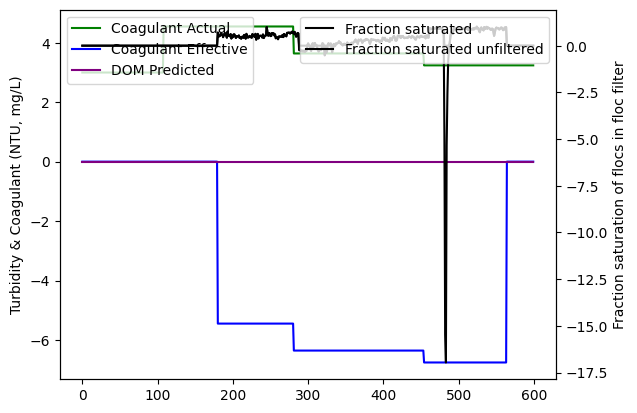

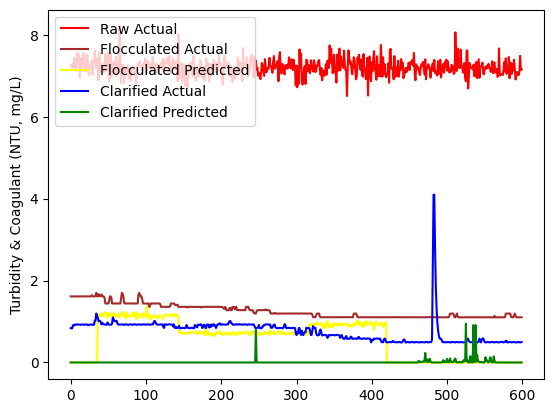

Standard Total Error: 273.6079712764773


In [ ]:
param = [6.443e-01,  5.663e+01,  7.033e-02] #result.x
savePlot = False

totalError = 0
totalNumPts = 0
for d in range(len(allData)):
    print(d)
    #Get specific dataset
    data = allData[d]

    table, error, num_h_pts = model(param,data,range(400,1000))

    print("Error:", error)
    print("Standard Error:", error/num_h_pts)
    totalError = totalError + error
    totalNumPts = totalNumPts + num_h_pts

    ##Plot C_P in floc filter (time vs height)
    # plt.imshow(C_P, cmap='Greys', interpolation='nearest', aspect='auto') # vmin=0.25)
    # plt.colorbar()
    # plt.ylabel("time")
    # plt.xlabel("ff height")
    # plt.title("Concentration of P in floc filter")
    # plt.show()

    ##Predicted + Actual plot of data
    fig, ax1 = plt.subplots()
    ax1.plot(table["coagulant_actual"],'green',label='Coagulant Actual')
    ax1.plot(table["coagulant_eff"],'blue',label='Coagulant Effective')
    ax1.plot(table["dom_pred"],'purple',label='DOM Predicted')
    plt.ylabel('Turbidity & Coagulant (NTU, mg/L)')
    plt.legend(loc ="upper left")
    ax2 = ax1.twinx()
    ax2.plot(table["floc_saturation"],'black',label='Fraction saturated')
    ax2.plot(table["floc_saturation_unfiltered"],'black',label='Fraction saturated unfiltered')
    plt.ylabel('Fraction saturation of flocs in floc filter')
    plt.legend(loc ="upper right")
    # plt.xlim([1000,1050])
    if savePlot:
        plt.savefig("plot{}_{}.png".format(d,error/num_h_pts))
        files.download("plot{}_{}.png".format(d,error/num_h_pts))
    plt.show()

    fig, ax1 = plt.subplots()
    ax1.plot(table["raw_actual"],'red',label='Raw Actual')
    ax1.plot(table["flocculated_actual"],'brown',label='Flocculated Actual')
    ax1.plot(table["flocculated_pred"],'yellow',label='Flocculated Predicted')
    ax1.plot(table["clarified_actual"],'blue',label='Clarified Actual')
    ax1.plot(table["clarified_pred"],'green',label='Clarified Predicted')
    plt.ylabel('Turbidity & Coagulant (NTU, mg/L)')
    plt.legend(loc ="upper left")
    # plt.xlim([1000,1050])
    if savePlot:
        plt.savefig("plot{}_{}.png".format(d,error/num_h_pts))
        files.download("plot{}_{}.png".format(d,error/num_h_pts))
    plt.show()

print("Standard Total Error:", totalError/totalNumPts)

In [ ]:
table.iloc[200]

time                  45089.810686
raw_actual                7.270489
clarified_actual          0.923972
clarified_pred            0.052350
flocculated_actual        1.358154
effluent_actual           0.142214
coagulant_actual          4.549817
coagulant_pred           14.549817
flocculated_pred          0.637498
floc_saturation           0.000000
dom_pred                 10.000000
Name: 200, dtype: float64

In [ ]:
for d in range(len(allData)):
    time_flocculation = 180    #s
    time_clarification = 720    #s
    height_ff = .72    #m
    dt = 5 #s, data interval    DEPENDS ON DATASET
    velocity = 0.001

    print(d)
    #Get specific dataset
    data = allData[d]
    C_raw_NTU = data['raw [NTU]'].values    # C_raw_NTU = np.repeat(10, 1000)
    C_coag = data['coagulant [mg Al/L]'].values
    C_settled_NTU = data['floc [NTU]'].values
    C_clarified_NTU = data['settled [NTU]'].values
    C_effluent_NTU = data['filtered [NTU]'].values

    C_raw = np.array(C_raw_NTU*1.7, dtype = float)   #mg/L (1.7mg/L = 1NTU)
    C_settled = np.array(C_settled_NTU*1.7, dtype = float)
    C_clarified = np.array(C_clarified_NTU*1.7, dtype = float)
    C_effluent = np.array(C_effluent_NTU*1.7, dtype = float)

    num_time_pts = len(C_raw)
    dh = velocity * dt
    num_h_pts = math.floor(height_ff/dh)
    num_pts_flocculator_response_delay = math.ceil(time_flocculation/dt)
    num_pts_clarifier_response_delay = math.ceil(time_clarification/dt)

    table = pd.DataFrame({
        "raw_actual": C_raw,
        "clarified_actual": C_clarified,
        "flocculated_actual": C_settled,
        "effluent_actual": C_effluent,
        "coagulant_actual": C_coag,
    })

    table[table['clarified_actual']!=1.15]
    table[table['clarified_actual']<1.19].index.tolist()

0


In [ ]:
table

,raw_actual,clarified_actual,flocculated_actual,effluent_actual,coagulant_actual
0,0.404600,0.136131,0.847651,0.204345,0.000000
1,0.302076,0.134896,0.809002,0.201990,0.000000
2,0.411633,0.138424,0.846274,0.202612,0.000000
3,0.479803,0.137339,0.865960,0.203052,0.000000
4,0.263392,0.133892,0.942441,0.201642,0.000000
...,...,...,...,...,...
3661,124.057739,0.650455,0.498913,0.353135,4.737053
3662,126.179751,0.649391,0.497636,0.360413,4.737053
3663,124.642588,0.650943,0.497702,0.358772,4.737053
3664,124.842767,0.649500,0.498488,0.359110,4.737053


# Acknowledgements & References

Andrew Pennock's Floc Interception Model, New Jersey Institute of Technology

Kuan-Mu Yao, Mohammad T. Habibian, and Charles R. O'Melia
Environmental Science & Technology 1971 5 (11), 1105-1112
DOI: 10.1021/es60058a005

AguaClara Textbook
*  Clarification introduction. Clarification Introduction - AguaClara v1.4.35 documentation. (n.d.). https://aguaclara.github.io/Textbook/Clarification/Clarifier_Intro.html
*  Coagulant Automation. Coagulant Automation - AguaClara v1.4.35 documentation. (n.d.). https://aguaclara.github.io/Textbook/Operation/Coagulant_Automation.html
*  AguaClara Hydraulic Flocculation Model. AguaClara Hydraulic Flocculation Model - AguaClara v1.4.35 documentation. (n.d.). https://aguaclara.github.io/Textbook/Flocculation/Floc_Model.html

## **Archive**

$$h=\begin{bmatrix} 0 \\ Iv \\ 2Iv \\ \vdots \\ (n-1)Iv \\ (n)Iv \end{bmatrix}$$
Storing at index i,
$$C_{primary}(h) = \begin{bmatrix} C_{primary,0} \\ C_{primary,1} \\ C_{primary,2} \\ \vdots \\ C_{primary,n-1} \\ C_{clarifiedPredicted}(i) \end{bmatrix} \leftarrow \begin{bmatrix} C_{primaryFlocculated}(i-m) \\ C_{primary,0}e^{-k_cα(i-m)(1-P_{flocSaturated})^{\frac{2}{3}}Iv} \\ C_{primary,1}e^{-k_cα(i-m-1)(1-P_{flocSaturated})^{\frac{2}{3}}Iv} \\ \vdots \\ C_{primary,n-1}e^{-k_cα(i-m-n+1)(1-P_{flocSaturated})^{\frac{2}{3}}Iv}\end{bmatrix}$$
where $Im = \theta_{flocculator}, In = \theta_{clarifier}$




$D = bI, g <= b$
$$C_{rawAverage} = \frac{1}{g}\sum_{x=i-g+1}^{i}C_{raw}(x-m-n)$$
$$C_{clarifiedErrorAverage} = \frac{1}{g}\sum_{x=i-g+1}^{i}(C_{clarifiedPredicted}-C_{clarified})$$
$$C_{DOM} = $$

$$[\text{max mass of primary particles that floc filter can possess}] = qM_{totalFloc}$$
$$[\text{current mass of primary particles in the floc filter}] = qP_{flocSaturated}(t)M_{totalFloc}$$
$$[\text{mass of primary particles wasted during Δt}] = qP_{flocSaturated}(t)[\text{mass of flocs wasted during Δt}]$$

Assuming the total mass of the floc filter remains constant with time, the mass of flocs wasted during $Δt$ equals the mass of flocs and primary particles that join the floc filter during $Δt$:
$$[\text{mass of flocs wasted during Δt}] = C_{flocEntering}a_{flocFilter}Δh + [\text{total mass of primary particles captured during Δt}]$$

$$[\text{total mass of primary particles captured during Δt}] = \sum_{h=0}^{h_{flocFilter}}C_{primaryCaptured}(t,h)a_{flocFilter}Δh = k_c(1-P_{flocSaturated}(t))^{\frac{2}{3}}a_{flocFilter}\sum_{h=0}^{h_{flocFilter}}C_{primary}(t,h)\frac{C_{coag}(t-\theta_{flocculator})}{C_{raw}(t-\theta_{flocculator})}Δh^2$$

Substituting into the equation for $P_{flocSaturated}$,
$$P_{flocSaturated}(t+Δt) = \frac{qP_{flocSaturated}(t)M_{totalFloc} + [1-qP_{flocSaturated}(t)]k_c(1-P_{flocSaturated}(t))^{\frac{2}{3}}a_{flocFilter}\sum_{h=0}^{h_{flocFilter}}C_{primary}(t,h)\frac{C_{coag}(t-\theta_{flocculator})}{C_{raw}(t-\theta_{flocculator})}Δh^2 - qP_{flocSaturated}(t)C_{flocEntering}(t)a_{flocFilter}Δh}{qM_{totalFloc}}$$

Rearranging,
$$\boxed{P_{flocSaturated}(t+Δt) = P_{flocSaturated}(t) + \frac{k_c(1-P_{flocSaturated}(t))^{\frac{2}{3}}[1-qP_{flocSaturated}(t)]a_{flocFilter}\sum_{h=0}^{h_{flocFilter}}C_{primary}(t,h)\frac{C_{coag}(t-\theta_{flocculator})}{C_{raw}(t-\theta_{flocculator})}Δh}{qM_{totalFloc}}Δh - \frac{P_{flocSaturated}(t)C_{flocEntering}(t)a_{flocFilter}}{M_{totalFloc}}Δh}$$

$C_{PPflocculated} = [\frac{C_{PACl}}{k_{pf}C_{PP,raw}}+C_{PPraw}^{-\frac{2}{3}}]^{-\frac{3}{2}}$

$\\C_{PPclarified}=C_{PPflocculated}e^{-k_c h_{FF} [1-k'\beta\frac{C_{PACl}}{C_{PPraw}}(1-S_{FF})^{\frac{2}{3}}]^{n}}$

$\\S_{FF} = \frac{C_{PPflocculated} - C_{PPclarified}}{q(C_{raw}-C_{PPclarified})}$

$k_c = πR_{floc}^2 N_{floc}$

$k_{pf} = \frac{3}{2\pi kk^{'}G\theta}(\rho_{PP}\frac{\pi}{6})^{\frac{2}{3}}$

$\frac{d[P]_{(h)}}{dh}=-k[P]_{(h)}[F_{flocFilter}]$

$k \propto R_F^2 (1-\alpha (1-S))^n$

$\alpha \propto \frac{[C]}{[P_{raw}]}$

$S = \frac{[P]_{in} - [P]_{out}}{q ([P]_{raw}-[P]_{out})}$